In [1]:
from utils.config import DATA_DIR, SAVED_MODELS_DIR, RAW_CONFIG
from pathlib import Path
from models.Unet import UNet
from utils.dataset2 import GLORYSDS2, TestSubset2
from utils.splitter import test_indices
import torch
import numpy as np

# Data

In [2]:
ds_path = DATA_DIR/RAW_CONFIG['datafile']
data = GLORYSDS2(ds_path, normalize=True)
test_idx = test_indices(Path(f"../../{RAW_CONFIG['test_indices']}"))
test_dataset = TestSubset2(data, test_idx, days=True)

Loaded existing test indices from ../../test_indices/1993_test_stratification_larger_regions(10_img).pt, test size: 2430


In [3]:
print(len(test_dataset[0]))
assert all(len(test_dataset[i]) == 3 for i in range(len(test_dataset)))

3


In [4]:
from torch.utils.data import DataLoader
# test_loader = DataLoader(test_data, batch_size=1, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)
print(len(next(iter(test_loader))))

3


In [5]:
model_path = SAVED_MODELS_DIR / "model: unet training_start_time: 20250522_101657 datafile: 1993-10-11-1993-10-12.nc strat: 1993_test_stratification_larger_regions(10_img).pt"/"best_model"
model = torch.load(model_path, map_location="cpu", weights_only=False)
model.eval()

unet

In [6]:
len(test_dataset.indices)

2430

In [7]:
test_dataset.indices[0].item()

0

In [8]:
region = test_dataset.getregions(test_dataset.indices[0].item())

In [9]:
len(region)

2

In [10]:
all_regions = [test_dataset.getregions(test_dataset.indices[i].item()) for i in range(min(len(test_dataset), 100))]

In [11]:
all_regions[1][0].shape

(6, 58, 58)

In [12]:
all_region_images = [all_regions[i][0] for i in range(len(all_regions))]
all_region_labels = [all_regions[i][1] for i in range(len(all_regions))]

print(len(all_region_images), len(all_region_labels))
print([all_region_images[i].shape for i in range(len(all_region_images))])
print([all_region_labels[i].shape for i in range(len(all_region_labels))])

print(all_region_labels[0].shape)
print(all_region_images[0].shape)

label_shape = ()
for i in range(len(all_region_labels[0].shape)):
    max_dim = max([all_region_labels[j].shape[i] for j in range(len(all_region_labels))])
    label_shape += (max_dim,)

image_shape = ()
for i in range(len(all_region_images[0].shape)):
    max_dim = max([all_region_images[j].shape[i] for j in range(len(all_region_images))])
    image_shape += (max_dim,)

def pad_to_shape(arr, out_shape):
    pad_width = []
    for actual, target in zip(arr.shape, out_shape):
        if actual < target:
            pad_width.append((0, target - actual))
        else:
            pad_width.append((0, 0))

    return np.pad(arr, pad_width, mode='constant', constant_values=0)

all_region_labels_padded = [pad_to_shape(all_region_labels[i], label_shape) for i in range(len(all_region_labels))]
all_region_images_padded = [pad_to_shape(all_region_images[i], image_shape) for i in range(len(all_region_images))]
print(len(all_region_labels_padded), all_region_labels_padded[0].shape)
print(len(all_region_images_padded), all_region_images_padded[0].shape)

assert len(all_region_labels_padded) == len(all_region_images_padded)

all_regions_combined = [np.concatenate((all_region_images_padded[i], all_region_labels_padded[i]), axis=0) for i in range(len(all_region_labels_padded))]

all_regions_combined_no_duplicates = [row for row in np.unique(np.stack(all_regions_combined), axis=0)]

all_regions_split = [np.split(all_regions_combined_no_duplicates[i], [-1]) for i in range(len(all_regions_combined_no_duplicates))]

print(len(all_regions_split), len(all_regions_split[0]))

100 100
[(6, 58, 58), (6, 58, 58), (6, 58, 58), (6, 58, 58), (6, 58, 58), (6, 58, 58), (6, 58, 58), (6, 58, 58), (6, 58, 58), (6, 58, 58), (6, 58, 58), (6, 58, 58), (6, 58, 58), (6, 58, 58), (6, 58, 58), (6, 58, 58), (6, 58, 58), (6, 58, 58), (6, 58, 58), (6, 58, 58), (6, 58, 58), (6, 58, 58), (6, 58, 58), (6, 58, 58), (6, 58, 58), (6, 58, 58), (6, 58, 58), (6, 58, 58), (6, 58, 58), (6, 58, 58), (6, 58, 58), (6, 58, 58), (6, 58, 58), (6, 58, 58), (6, 58, 58), (6, 58, 58), (6, 58, 58), (6, 58, 58), (6, 58, 58), (6, 58, 58), (6, 58, 58), (6, 58, 58), (6, 58, 58), (6, 58, 58), (6, 58, 58), (6, 58, 58), (6, 58, 58), (6, 58, 58), (6, 58, 58), (6, 58, 58), (6, 58, 58), (6, 58, 58), (6, 58, 58), (6, 58, 58), (6, 58, 58), (6, 58, 58), (6, 58, 58), (6, 58, 58), (6, 58, 58), (6, 58, 58), (6, 58, 58), (6, 58, 58), (6, 58, 58), (6, 58, 58), (6, 58, 58), (6, 58, 58), (6, 58, 58), (6, 58, 58), (6, 58, 58), (6, 58, 58), (6, 58, 58), (6, 58, 58), (6, 58, 58), (6, 58, 58), (6, 58, 58), (6, 58, 58), (6,

In [20]:
outputs = []
num_outputs = 1000

with torch.no_grad():
    for i, batch in enumerate(test_loader):
        print(f"Processing batch {i}, len(batch)={len(batch)}")

        if len(batch) == 3:
            images, labels, days = batch
            day_value = days.item() if isinstance(days, torch.Tensor) else days[0]
            print(f"Day: {day_value}")
            preds = model(images)
            outputs.append((preds, labels, days))
        elif len(batch) == 2:
            images, labels = batch
            print("Warning: No day information available, using default day=0")
            preds = model(images)
            default_day = torch.tensor([0])
            outputs.append((preds, labels, default_day))
        if i >= num_outputs:
            break

Processing batch 0, len(batch)=3
Day: 0
Processing batch 1, len(batch)=3
Day: 1
Processing batch 2, len(batch)=3
Day: 2
Processing batch 3, len(batch)=3
Day: 3
Processing batch 4, len(batch)=3
Day: 4
Processing batch 5, len(batch)=3
Day: 5
Processing batch 6, len(batch)=3
Day: 0
Processing batch 7, len(batch)=3
Day: 1
Processing batch 8, len(batch)=3
Day: 2
Processing batch 9, len(batch)=3
Day: 3
Processing batch 10, len(batch)=3
Day: 4
Processing batch 11, len(batch)=3
Day: 5
Processing batch 12, len(batch)=3
Day: 0
Processing batch 13, len(batch)=3
Day: 1
Processing batch 14, len(batch)=3
Day: 2
Processing batch 15, len(batch)=3
Day: 3
Processing batch 16, len(batch)=3
Day: 4
Processing batch 17, len(batch)=3
Day: 5
Processing batch 18, len(batch)=3
Day: 0
Processing batch 19, len(batch)=3
Day: 1
Processing batch 20, len(batch)=3
Day: 2
Processing batch 21, len(batch)=3
Day: 3
Processing batch 22, len(batch)=3
Day: 4
Processing batch 23, len(batch)=3
Day: 5
Processing batch 24, len(b

In [22]:
import matplotlib.pyplot as plt
from utils.handy_plotting_func import plot_var
import numpy as np
import torch.nn.functional as F

samples_to_plot = 50
outputs_subset = outputs[::5]

max=20

fig, axs = plt.subplots(figsize=(12, 6*len(outputs_subset)), ncols=2, nrows=len(outputs_subset))
for i, output_item in enumerate(outputs_subset):
        pred, label, day = output_item
        day = day.item() if isinstance(day, torch.Tensor) else day[0]
        print(f"Day: {day}")
        pred_np = pred.numpy() if isinstance(pred, torch.Tensor) else pred
        label_np = label.numpy() if isinstance(label, torch.Tensor) else label
        
        pred_unnormalized = data.unnormalize_annot(pred_np)
        label_unnormalized = data.unnormalize_annot(label_np)

        pred_squeezed = np.squeeze(pred_unnormalized, axis=(0, 1))
        label_squeezed = np.squeeze(label_unnormalized, axis=(0, 1))

        #pred_squeezed = np.squeeze(pred_np, axis=(0, 1))
        #label_squeezed = np.squeeze(label_np, axis=(0, 1))
        

        plot_var(axs[i, 0], fig, pred_squeezed, f"Predicted Mixed Layer Depth", max=max)
        plot_var(axs[i, 1], fig, label_squeezed, f"Actual Mixed Layer Depth", max=max)
        pred_tensor = torch.from_numpy(pred_np) if not isinstance(pred, torch.Tensor) else pred
        label_tensor = torch.from_numpy(label_np) if not isinstance(label, torch.Tensor) else label

        pred_tensor_unnormalized = torch.from_numpy(pred_unnormalized) if not isinstance(pred_unnormalized, torch.Tensor) else pred_unnormalized
        label_tensor_unnormalized = torch.from_numpy(label_unnormalized) if not isinstance(label_unnormalized, torch.Tensor) else label_unnormalized

        normalized_loss = F.mse_loss(pred_tensor, label_tensor)
        unnormalized_loss = F.mse_loss(pred_tensor_unnormalized, label_tensor_unnormalized)

        axs[i, 0].set_title(f"Predicted MLD\nUnnormalized MSE Loss: {unnormalized_loss.item():.8f}\nNormalized MSE Loss: {normalized_loss.item():.8f}")
        axs[i, 1].set_title(f"Actual MLD\nUnnormalized MSE Loss: {unnormalized_loss.item():.8f}\nNormalized MSE Loss: {normalized_loss.item():.8f}")
plt.tight_layout()

Day: 0
Day: 5
Day: 4
Day: 3
Day: 2
Day: 1
Day: 0
Day: 5
Day: 4
Day: 3
Day: 2
Day: 1
Day: 0
Day: 5
Day: 4
Day: 3
Day: 2
Day: 1
Day: 0
Day: 5
Day: 4
Day: 3
Day: 2
Day: 1
Day: 0
Day: 5
Day: 4
Day: 3
Day: 2
Day: 1
Day: 0
Day: 5
Day: 4
Day: 3
Day: 2
Day: 1
Day: 0
Day: 5
Day: 4
Day: 3
Day: 2
Day: 1
Day: 0
Day: 5
Day: 4
Day: 3
Day: 2
Day: 1
Day: 0
Day: 5
Day: 4
Day: 3
Day: 2
Day: 1
Day: 0
Day: 5
Day: 4
Day: 3
Day: 2
Day: 1
Day: 0
Day: 5
Day: 4
Day: 3
Day: 2
Day: 1
Day: 0
Day: 5
Day: 4
Day: 3
Day: 2
Day: 1
Day: 0
Day: 5
Day: 4
Day: 3


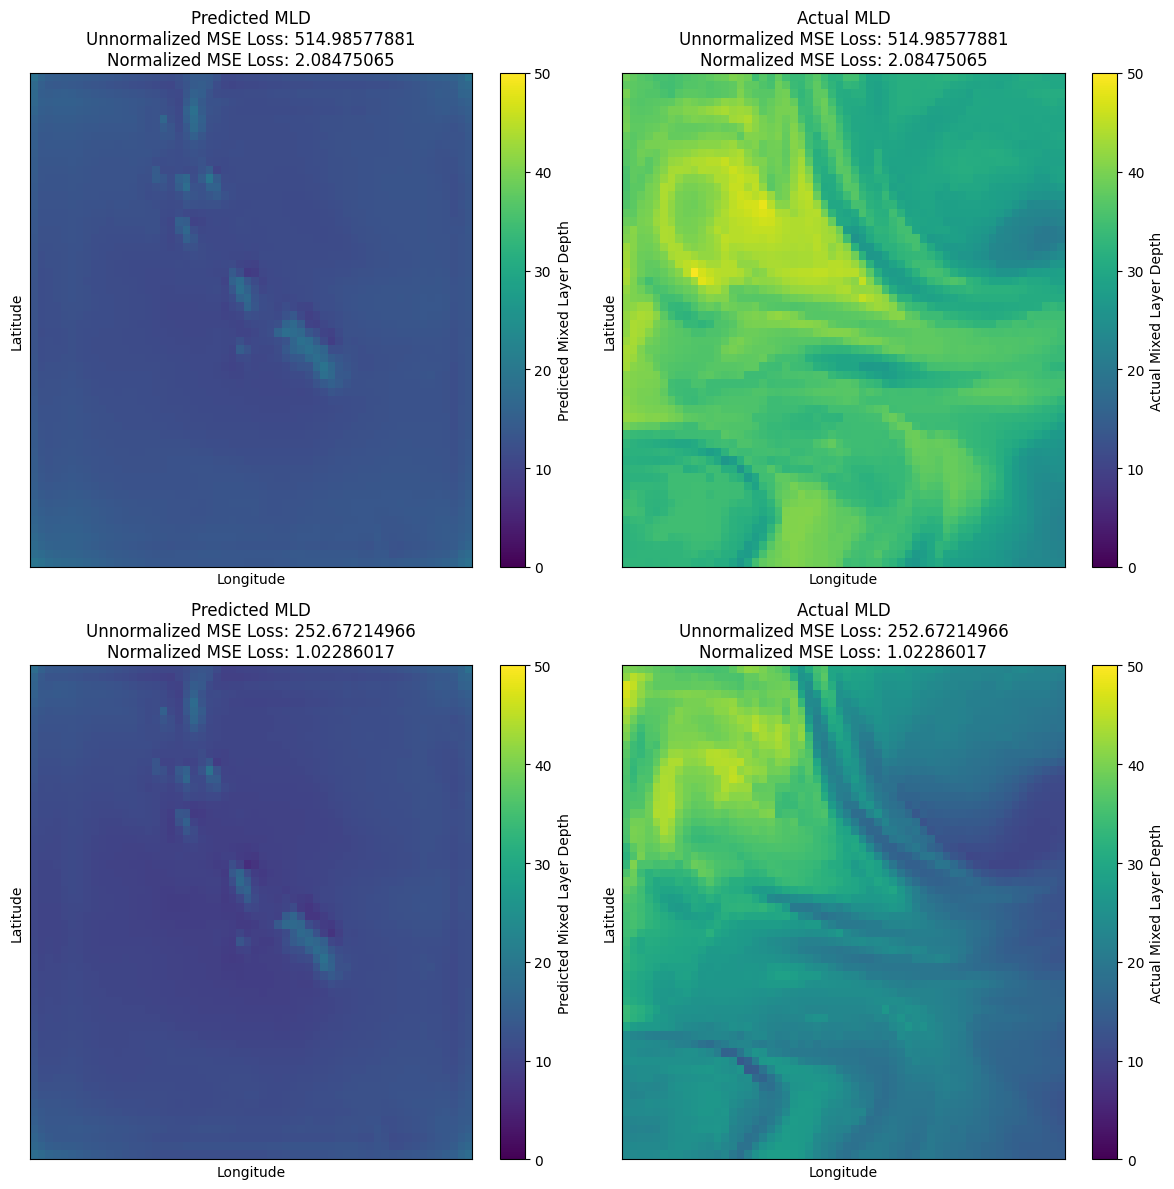

In [13]:
import matplotlib.pyplot as plt
from utils.handy_plotting_func import plot_var
import numpy as np
import torch.nn.functional as F

fig, axes = plt.subplots(figsize=(12, 6*len(all_regions_split)), ncols=2, nrows=len(all_regions_split))
maximum=50

with torch.no_grad():
    for i, (image, label) in enumerate(all_regions_split):

        pred = model(torch.from_numpy(image).unsqueeze(0))
        label = np.expand_dims(label, axis=0)
        pred_np = pred.numpy() if isinstance(pred, torch.Tensor) else pred
        label_np = label.numpy() if isinstance(label, torch.Tensor) else label

        pred_unnormalized = data.unnormalize_annot(pred_np)
        label_unnormalized = data.unnormalize_annot(label_np)

        pred_squeezed = np.squeeze(pred_unnormalized, axis=(0, 1))
        label_squeezed = np.squeeze(label_unnormalized, axis=(0, 1))

        plot_var(axes[i, 0], fig, pred_squeezed, f"Predicted Mixed Layer Depth", max=maximum)
        plot_var(axes[i, 1], fig, label_squeezed, f"Actual Mixed Layer Depth", max=maximum)

        pred_tensor = torch.from_numpy(pred_np) if not isinstance(pred, torch.Tensor) else pred
        label_tensor = torch.from_numpy(label_np) if not isinstance(label, torch.Tensor) else label
        pred_tensor_unnormalized = torch.from_numpy(pred_unnormalized) if not isinstance(pred_unnormalized, torch.Tensor) else pred_unnormalized
        label_tensor_unnormalized = torch.from_numpy(label_unnormalized) if not isinstance(label_unnormalized, torch.Tensor) else label_unnormalized
        normalized_loss = F.mse_loss(pred_tensor, label_tensor)
        unnormalized_loss = F.mse_loss(pred_tensor_unnormalized, label_tensor_unnormalized)
        axes[i, 0].set_title(f"Predicted MLD\nUnnormalized MSE Loss: {unnormalized_loss.item():.8f}\nNormalized MSE Loss: {normalized_loss.item():.8f}")
        axes[i, 1].set_title(f"Actual MLD\nUnnormalized MSE Loss: {unnormalized_loss.item():.8f}\nNormalized MSE Loss: {normalized_loss.item():.8f}")
plt.tight_layout()
plt.show()
        